### Import Libraries

In [29]:
import pandas as pd
import numpy as np

### Read Dataset

In [30]:
df = pd.read_excel("marketing_campaign.xlsx")

In [31]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

### Check Null Values

In [33]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [34]:
df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\haris\AppData\Local\Temp\ipykernel_23388\1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [35]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

### Check Dupilcate Records

In [36]:
df.duplicated().sum()

np.int64(0)

### Check DataTypes

In [37]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

### Clean Marital Status

In [38]:
df['Marital_Status'] = df['Marital_Status'].replace({
'Alone':'Single',
'Widow':'Single',
'Divorced':'Single',
'YOLO':'Single',
'Absurd':'Single',
'Together':'Married'
})

In [39]:
df['Marital_Status'].value_counts()

Marital_Status
Married    1444
Single      796
Name: count, dtype: int64

### Clean Education

In [40]:
df['Education'] = df['Education'].replace({#
'Basic':'Graduation'
})

In [41]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', '2n Cycle'], dtype=object)

### Label Encoding

In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
le = LabelEncoder()

In [44]:
df['Marital_StatusEnc'] = le.fit_transform(df['Marital_Status'])
df['Education_Enc'] = le.fit_transform(df['Education'])

In [45]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

### Feature Engineering

In [46]:
df['MntNonVeg_Prodicuts'] = df['MntMeatProducts'] + df['MntFishProducts']

In [47]:
df['TotKids'] = df[['Kidhome','Teenhome']].sum(axis=1)

### Drop Unnecessary Columns

In [48]:
df = df.drop([
'Marital_Status',
'Education',
'MntMeatProducts',
'MntFishProducts',
'Kidhome',
'Teenhome',
'AcceptedCmp1',
'AcceptedCmp2',
'AcceptedCmp3',
'AcceptedCmp4',
'AcceptedCmp5',
'Response'
], axis=1)

In [49]:
df.columns

Index(['ID', 'Year_Birth', 'Income', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Z_CostContact', 'Z_Revenue',
       'Marital_StatusEnc', 'Education_Enc', 'MntNonVeg_Prodicuts', 'TotKids'],
      dtype='object')

In [50]:
df.dtypes

ID                              int64
Year_Birth                      int64
Income                        float64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
Complain                        int64
Z_CostContact                   int64
Z_Revenue                       int64
Marital_StatusEnc               int64
Education_Enc                   int64
MntNonVeg_Prodicuts             int64
TotKids                         int64
dtype: object

In [51]:
df.head()

,ID,Year_Birth,Income,Dt_Customer,Recency,MntWines,MntFruits,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Marital_StatusEnc,Education_Enc,MntNonVeg_Prodicuts,TotKids
0,5524,1957,58138.0,2012-09-04,58,635,88,88,88,3,...,10,4,7,0,3,11,1,1,718,0
1,2174,1954,46344.0,2014-03-08,38,11,1,1,6,2,...,1,2,5,0,3,11,1,1,8,2
2,4141,1965,71613.0,2013-08-21,26,426,49,21,42,1,...,2,10,4,0,3,11,0,1,238,0
3,6182,1984,26646.0,2014-02-10,26,11,4,3,5,2,...,0,4,6,0,3,11,0,1,30,1
4,5324,1981,58293.0,2014-01-19,94,173,43,27,15,5,...,3,6,5,0,3,11,0,3,164,1


### Year_Birth to Age

In [52]:
df['Age'] = 2024 - df['Year_Birth']


In [53]:
df[['Year_Birth','Age']].head()

,Year_Birth,Age
0,1957,67
1,1954,70
2,1965,59
3,1984,40
4,1981,43


In [54]:
df = df.drop('Year_Birth', axis=1)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Income               2240 non-null   float64       
 2   Dt_Customer          2240 non-null   datetime64[ns]
 3   Recency              2240 non-null   int64         
 4   MntWines             2240 non-null   int64         
 5   MntFruits            2240 non-null   int64         
 6   MntSweetProducts     2240 non-null   int64         
 7   MntGoldProds         2240 non-null   int64         
 8   NumDealsPurchases    2240 non-null   int64         
 9   NumWebPurchases      2240 non-null   int64         
 10  NumCatalogPurchases  2240 non-null   int64         
 11  NumStorePurchases    2240 non-null   int64         
 12  NumWebVisitsMonth    2240 non-null   int64         
 13  Complain             2240 non-nul

In [56]:
df.head()

,ID,Income,Dt_Customer,Recency,MntWines,MntFruits,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Marital_StatusEnc,Education_Enc,MntNonVeg_Prodicuts,TotKids,Age
0,5524,58138.0,2012-09-04,58,635,88,88,88,3,8,...,4,7,0,3,11,1,1,718,0,67
1,2174,46344.0,2014-03-08,38,11,1,1,6,2,1,...,2,5,0,3,11,1,1,8,2,70
2,4141,71613.0,2013-08-21,26,426,49,21,42,1,8,...,10,4,0,3,11,0,1,238,0,59
3,6182,26646.0,2014-02-10,26,11,4,3,5,2,2,...,4,6,0,3,11,0,1,30,1,40
4,5324,58293.0,2014-01-19,94,173,43,27,15,5,5,...,6,5,0,3,11,0,3,164,1,43


## Total Purchases

In [57]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [58]:
print(df.columns)

Index(['ID', 'Income', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Z_CostContact', 'Z_Revenue',
       'Marital_StatusEnc', 'Education_Enc', 'MntNonVeg_Prodicuts', 'TotKids',
       'Age', 'Total_Purchases'],
      dtype='object')


In [59]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntSweetProducts'] +
    df['MntGoldProds'] +
    df['MntNonVeg_Prodicuts']
)

In [60]:
print(df[['Total_Spending']].head())

   Total_Spending
0            1617
1              27
2             776
3              53
4             422


### EDA Data Visualisation

## Income Distribution

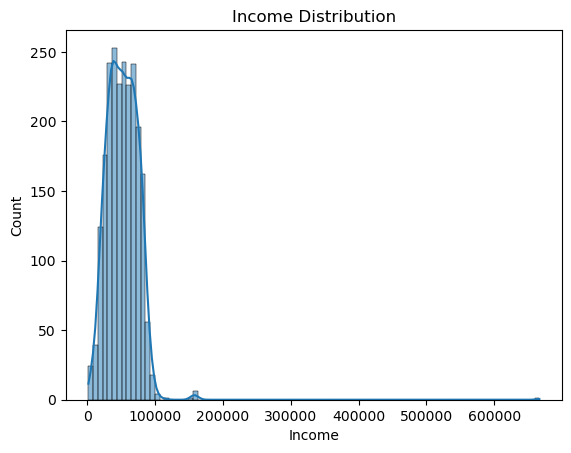

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

## Age Distribution

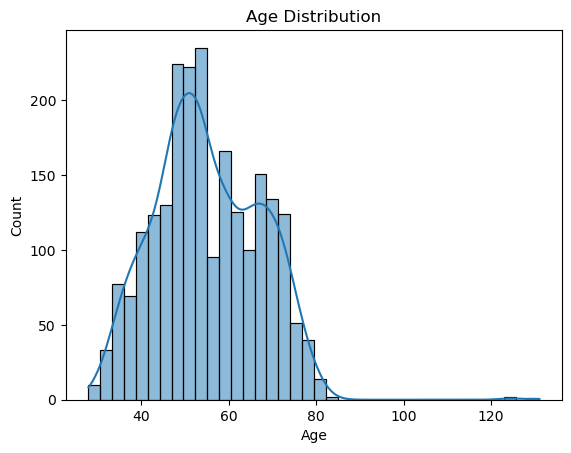

In [62]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

## Total Spending Distribution

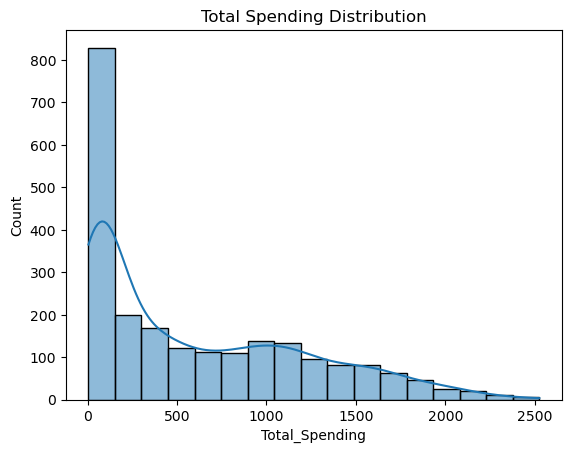

In [63]:
sns.histplot(df['Total_Spending'], kde=True)
plt.title("Total Spending Distribution")
plt.show()

## Outlier Detection

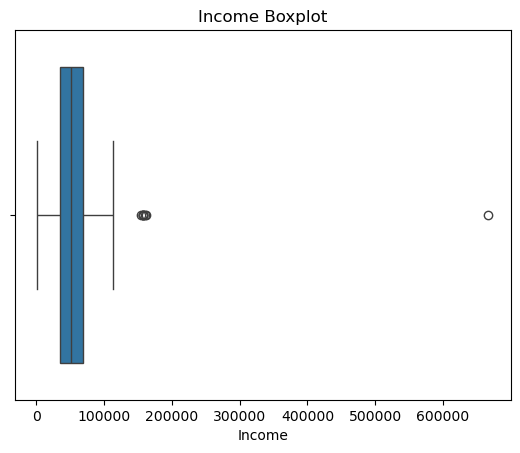

In [64]:
sns.boxplot(x=df['Income'])
plt.title("Income Boxplot")
plt.show()

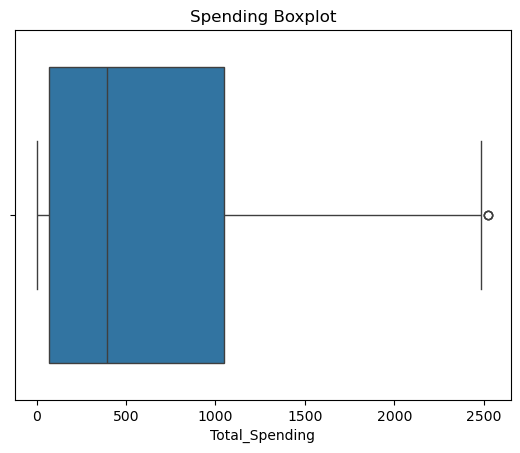

In [65]:
sns.boxplot(x=df['Total_Spending'])
plt.title("Spending Boxplot")
plt.show()

## Income and spending

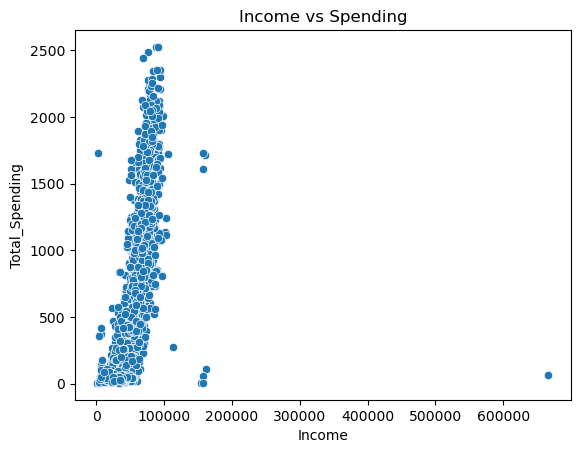

In [66]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Spending")
plt.show()

## Age vs Spending

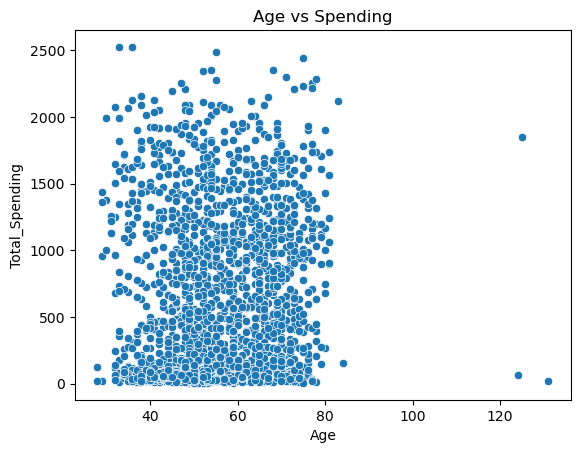

In [67]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.title("Age vs Spending")
plt.show()

## Correlation Heatmap

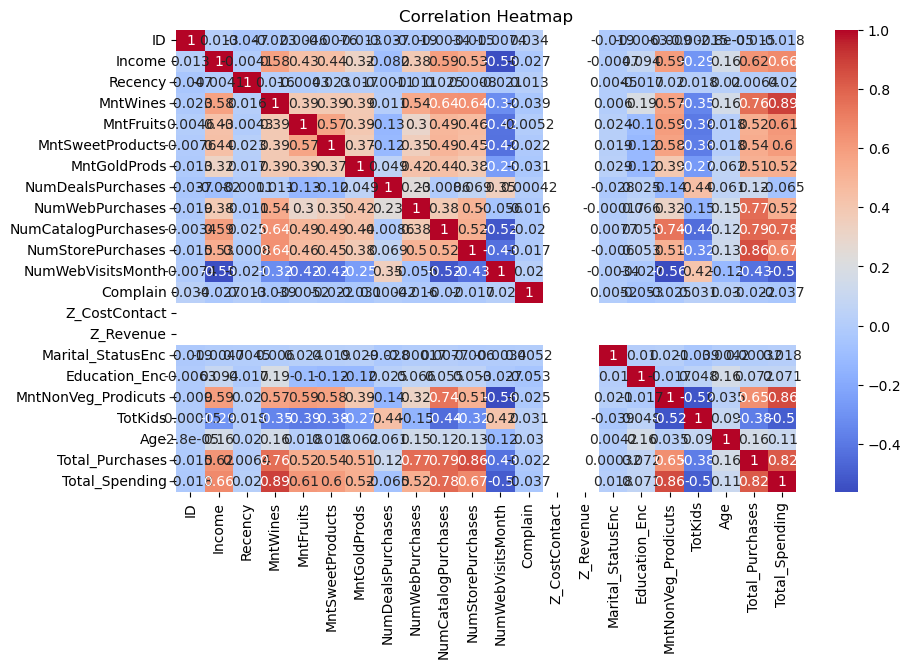

In [68]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Marital Status vs Spending

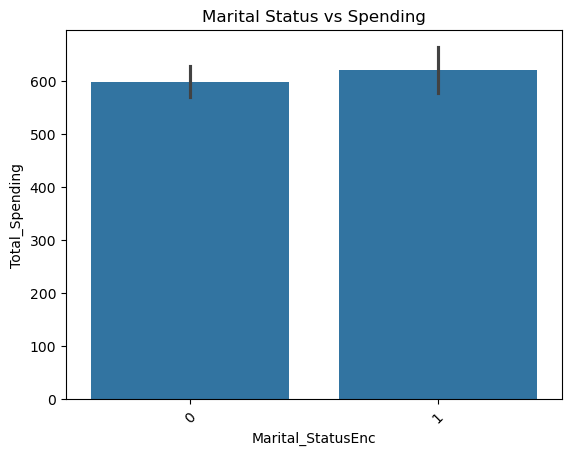

In [69]:
sns.barplot(x='Marital_StatusEnc', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title("Marital Status vs Spending")
plt.show()

## Children and Spending

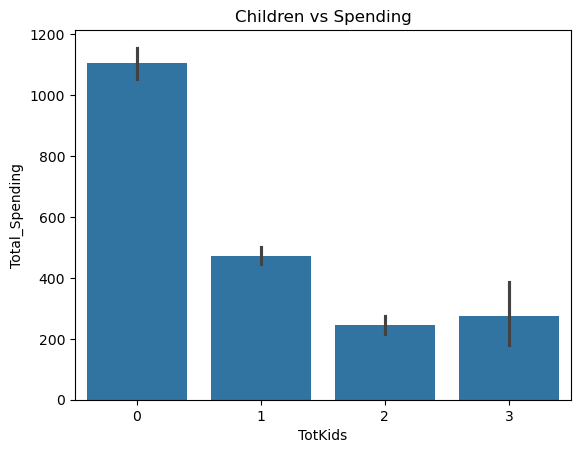

In [70]:
sns.barplot(x='TotKids', y='Total_Spending', data=df)
plt.title("Children vs Spending")
plt.show()

## Model Building

### Select Features

In [71]:
features = [
    'Income',
    'Age',
    'Total_Spending',
    'TotKids',
    'Recency',
    'Total_Purchases'
]

### Scaling

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

## Elbow Method

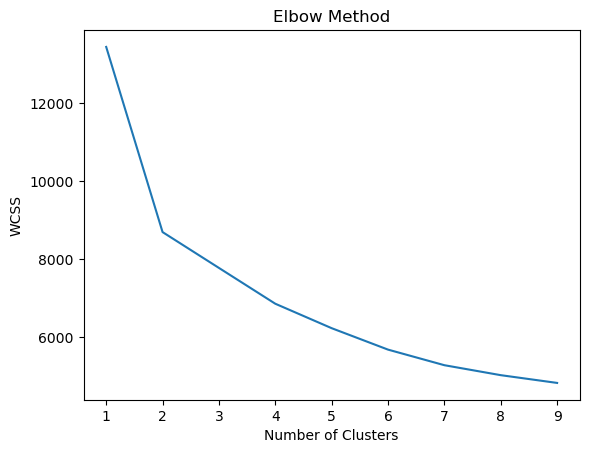

In [73]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=12)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

## Apply K-Means

In [74]:
kmeans = KMeans(n_clusters=4, random_state=12)
df['Cluster'] = kmeans.fit_predict(scaled_data)

## Cluster Summary

In [75]:
cluster_summary = df.groupby('Cluster')[features].mean().round(0)
print(cluster_summary)

          Income   Age  Total_Spending  TotKids  Recency  Total_Purchases
Cluster                                                                  
0        69903.0  58.0          1176.0      1.0     74.0             19.0
1        31630.0  47.0           120.0      1.0     49.0              6.0
2        44190.0  61.0           194.0      2.0     50.0              8.0
3        70708.0  56.0          1119.0      1.0     22.0             19.0


## Cluster Size

In [76]:
df['Cluster'].value_counts()

Cluster
1    682
2    539
0    532
3    487
Name: count, dtype: int64

In [77]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, df['Cluster'])
print(score)

0.2143661429948834


### Save the Trained Model

In [78]:
import joblib

joblib.dump(kmeans, "kmeans_customer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [79]:
import os
os.makedirs("templates", exist_ok=True)
